In [5]:
import numpy as np
import skimage
import matplotlib.pyplot as plt

In [18]:
cameraman_img = skimage.io.imread('./Images/cameraman.tif', as_gray=True)
cameraman_img_resized = skimage.transform.resize(cameraman_img, (256, 256), anti_aliasing=True)
lena_img = skimage.io.imread('./Images/lena_gray_256.tif', as_gray=True)
lena_img_resized = lena_img.astype(np.float32) / 255.0

--- Mask Creation ---
Mask shape: (256, 256)
Sampling ratio (r): 0.2
Target samples (M): 13107
Actual samples in mask: 13107


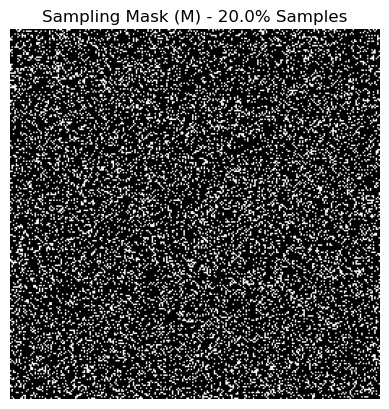

In [24]:
SAMPLING_RATIO = 0.2  
N = cameraman_img_resized.size      
M_count = int(N * SAMPLING_RATIO)  

np.random.seed(42)

mask_flat = np.zeros(N, dtype=np.float64)

# Choose M unique random indices (from 0 to N-1)
# replace=False ensures we get M *unique* samples 
indices = np.random.choice(N, M_count, replace=False)

# Set the chosen indices to 1.0
mask_flat[indices] = 1.0

# Reshape the flat mask to the 2D image shape
mask = mask_flat.reshape(cameraman_img_resized.shape)

# --- 3. Verify ---
print(f"--- Mask Creation ---")
print(f"Mask shape: {mask.shape}")
print(f"Sampling ratio (r): {SAMPLING_RATIO}")
print(f"Target samples (M): {M_count}")
print(f"Actual samples in mask: {np.count_nonzero(mask)}")

# --- 4. Visualize ---
plt.imshow(mask, cmap='gray')
plt.title(f"Sampling Mask (M) - {SAMPLING_RATIO*100}% Samples")
plt.axis('off')
plt.show()

--- Initial Image Creation ---
L2 norm of sensed signal : 59.9086
Target L2 norm for noise : 1.8945
Actual L2 norm of added noise: 1.8945


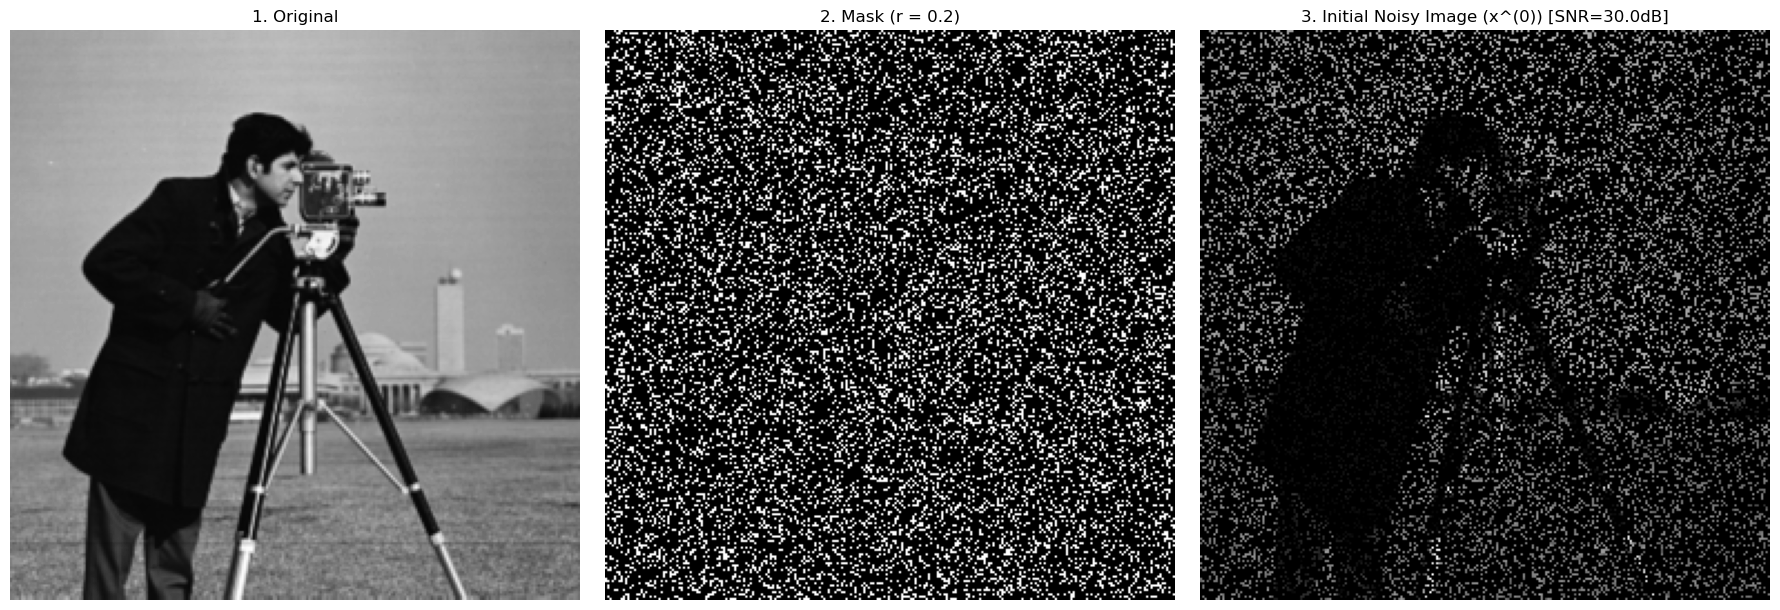

In [26]:
SNR_DB = 30.0

wx_true = cameraman_img_resized * mask

l2_signal = np.linalg.norm(wx_true)

# ||eta||2 = ||Wx*||_2 / (10^(SNR_dB/20)) required for desired SNR
l2_noise = l2_signal / (10**(SNR_DB / 20.0))

np.random.seed(42) 
# randn generates samples from standard normal distribution
eta = np.random.randn(*cameraman_img_resized.shape) #unpacking (256,256)
eta_masked = eta * mask

l2_eta_masked = np.linalg.norm(eta_masked)

# Scale the masked noise to have the *exact* L2 norm we calculated
if l2_eta_masked > 0:
    eta_scaled = eta_masked * (l2_noise / l2_eta_masked)
else:
    eta_scaled = 0.0

x_0 = wx_true + eta_scaled

print("--- Initial Image Creation ---")
print(f"L2 norm of sensed signal : {l2_signal:.4f}")
print(f"Target L2 norm for noise : {l2_noise:.4f}")
print(f"Actual L2 norm of added noise: {np.linalg.norm(eta_scaled):.4f}")


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cameraman_img_resized, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("1. Original")
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title(f"2. Mask (r = {SAMPLING_RATIO})")
axes[1].axis('off')

axes[2].imshow(x_0, cmap='gray', vmin=0, vmax=1)
axes[2].set_title(f"3. Initial Noisy Image (x^(0)) [SNR={SNR_DB}dB]")
axes[2].axis('off')

plt.tight_layout()
plt.show()